In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('titanic_dataset.csv')
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
data = data.set_index('PassengerId')

In [4]:
data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
data.index.name

'PassengerId'

In [6]:
data.shape

(891, 11)

In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    str    
 3   Sex       891 non-null    str    
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    str    
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    str    
 10  Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 111.9 KB


In [8]:
data.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
data.columns

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [10]:
data.dtypes

Survived      int64
Pclass        int64
Name            str
Sex             str
Age         float64
SibSp         int64
Parch         int64
Ticket          str
Fare        float64
Cabin           str
Embarked        str
dtype: object

In [11]:
data.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [12]:
data['Age'] = data['Age'].fillna(data['Age'].median())

data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

data['Cabin'] = data['Cabin'].fillna('Unknown')

In [13]:
data.isnull().sum()

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Cabin       0
Embarked    0
dtype: int64

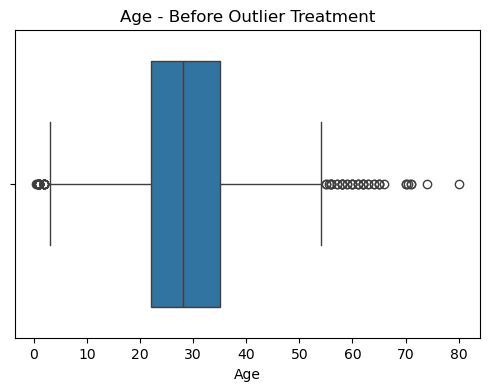

In [14]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=data['Age'])
plt.title('Age - Before Outlier Treatment')
plt.show()

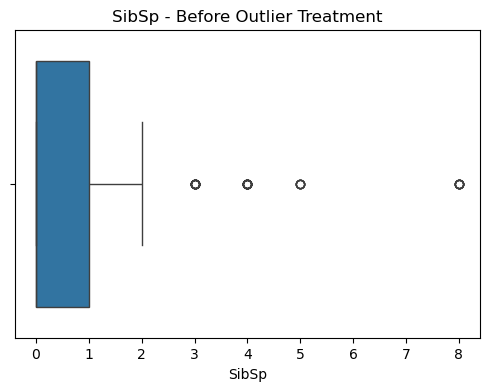

In [15]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=data['SibSp'])
plt.title('SibSp - Before Outlier Treatment')
plt.show()

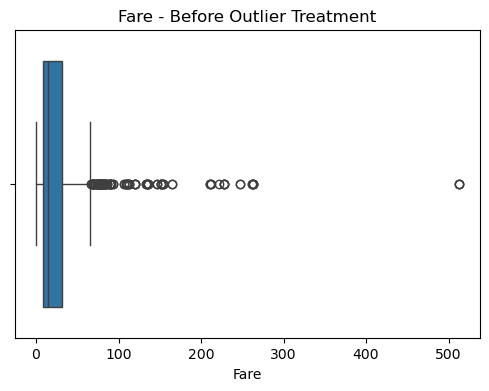

In [16]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=data['Fare'])
plt.title('Fare - Before Outlier Treatment')
plt.show()

In [17]:
def find_outliers(column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    outliers = data[
        (data[column] < lower_limit) |
        (data[column] > upper_limit)
    ]
    
    print(f'{column}')
    print('Lower Limit:', lower_limit)
    print('Upper Limit:', upper_limit)
    print('Number of Outliers:', len(outliers))
    print()

for column in ['Age', 'SibSp', 'Fare']:
    find_outliers(column)

Age
Lower Limit: 2.5
Upper Limit: 54.5
Number of Outliers: 66

SibSp
Lower Limit: -1.5
Upper Limit: 2.5
Number of Outliers: 46

Fare
Lower Limit: -26.724
Upper Limit: 65.6344
Number of Outliers: 116



In [18]:
def cap_outliers(column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    data[column] = data[column].clip(
        lower=lower_limit,
        upper=upper_limit
    )

In [19]:
for column in ['Age', 'SibSp', 'Fare']:
    cap_outliers(column)

In [20]:
for column in ['Age', 'SibSp', 'Fare']:
    find_outliers(column)

Age
Lower Limit: 2.5
Upper Limit: 54.5
Number of Outliers: 0

SibSp
Lower Limit: -1.5
Upper Limit: 2.5
Number of Outliers: 0

Fare
Lower Limit: -26.724
Upper Limit: 65.6344
Number of Outliers: 0



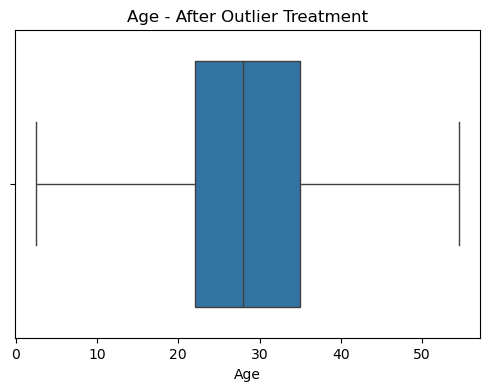

In [21]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=data['Age'])
plt.title('Age - After Outlier Treatment')
plt.show()

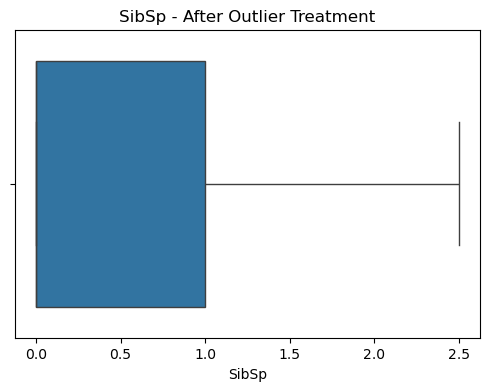

In [22]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=data['SibSp'])
plt.title('SibSp - After Outlier Treatment')
plt.show()

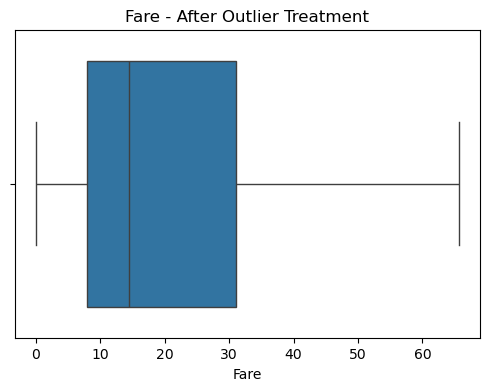

In [23]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=data['Fare'])
plt.title('Fare - After Outlier Treatment')
plt.show()

In [24]:
X = data.drop('Survived', axis=1)
y = data['Survived']

In [25]:
X.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,
1,3,"Braund, Mr. Owen Harris",male,22.0,1.0,0,A/5 21171,7.2500,Unknown,S
2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1.0,0,PC 17599,65.6344,C85,C
3,3,"Heikkinen, Miss. Laina",female,26.0,0.0,0,STON/O2. 3101282,7.9250,Unknown,S
4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1.0,0,113803,53.1000,C123,S
5,3,"Allen, Mr. William Henry",male,35.0,0.0,0,373450,8.0500,Unknown,S


In [26]:
y.head()

PassengerId
1    0
2    1
3    1
4    1
5    0
Name: Survived, dtype: int64

In [27]:
X = X.drop(['Name', 'Ticket', 'Cabin'], axis=1)

X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
PassengerId,,,,,,,
1,3,male,22.0,1.0,0,7.2500,S
2,1,female,38.0,1.0,0,65.6344,C
3,3,female,26.0,0.0,0,7.9250,S
4,1,female,35.0,1.0,0,53.1000,S
5,3,male,35.0,0.0,0,8.0500,S


In [29]:
import warnings
warnings.filterwarnings("ignore")

In [30]:
numerical_columns = X.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = X.select_dtypes(include=['object']).columns

print("Numerical Columns:")
print(list(numerical_columns))

print("\nCategorical Columns:")
print(list(categorical_columns))

Numerical Columns:
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

Categorical Columns:
['Sex', 'Embarked']


In [31]:
X = pd.get_dummies(
    X,
    columns=['Sex', 'Embarked'],
    drop_first=True
)

X.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
PassengerId,,,,,,,,
1,3,22.0,1.0,0,7.2500,True,False,True
2,1,38.0,1.0,0,65.6344,False,False,False
3,3,26.0,0.0,0,7.9250,False,False,True
4,1,35.0,1.0,0,53.1000,False,False,True
5,3,35.0,0.0,0,8.0500,True,False,True


In [32]:
X.columns

Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q',
       'Embarked_S'],
      dtype='str')

In [33]:
X = X.astype(int)

X.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
PassengerId,,,,,,,,
1,3,22,1,0,7,1,0,1
2,1,38,1,0,65,0,0,0
3,3,26,0,0,7,0,0,1
4,1,35,1,0,53,0,0,1
5,3,35,0,0,8,1,0,1


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

### Scaling

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

### Logistic Regression

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_scaled, y_train)

y_pred_logistic = logistic_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_logistic))
print("Precision:", precision_score(y_test, y_pred_logistic))
print("Recall:", recall_score(y_test, y_pred_logistic))
print("F1 Score:", f1_score(y_test, y_pred_logistic))

Accuracy: 0.7821229050279329
Precision: 0.7419354838709677
Recall: 0.6666666666666666
F1 Score: 0.7022900763358778


In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_logistic))

              precision    recall  f1-score   support

           0       0.80      0.85      0.83       110
           1       0.74      0.67      0.70        69

    accuracy                           0.78       179
   macro avg       0.77      0.76      0.77       179
weighted avg       0.78      0.78      0.78       179



### KNN

In [38]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()

knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn))

Accuracy: 0.776536312849162
Precision: 0.7377049180327869
Recall: 0.6521739130434783
F1 Score: 0.6923076923076923


### SVM

In [39]:
from sklearn.svm import SVC

svm_model = SVC()

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1 Score:", f1_score(y_test, y_pred_svm))

Accuracy: 0.8100558659217877
Precision: 0.8431372549019608
Recall: 0.6231884057971014
F1 Score: 0.7166666666666667


### Decision Tree

In [40]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

y_pred_dt = decision_tree_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))

Accuracy: 0.8268156424581006
Precision: 0.7878787878787878
Recall: 0.7536231884057971
F1 Score: 0.7703703703703704


### Random Forest

In [41]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    random_state=42
)

random_forest_model.fit(X_train, y_train)

y_pred_rf = random_forest_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

Accuracy: 0.7988826815642458
Precision: 0.7538461538461538
Recall: 0.7101449275362319
F1 Score: 0.7313432835820896


### Gradient Boosting

In [45]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting_model = GradientBoostingClassifier(
    random_state=42
)

gradient_boosting_model.fit(X_train, y_train)

y_pred_gb = gradient_boosting_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall:", recall_score(y_test, y_pred_gb))
print("F1 Score:", f1_score(y_test, y_pred_gb))

Accuracy: 0.7988826815642458
Precision: 0.7894736842105263
Recall: 0.6521739130434783
F1 Score: 0.7142857142857143


In [46]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'SVM',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting',
    ],
    
    'Accuracy': [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    
    'Precision': [
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_gb)
    ],
    
    'Recall': [
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_gb)
    ],
    
    'F1 Score': [
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb)
    ]
})

results.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
3,Decision Tree,0.826816,0.787879,0.753623,0.770370
2,SVM,0.810056,0.843137,0.623188,0.716667
4,Random Forest,0.798883,0.753846,0.710145,0.731343
5,Gradient Boosting,0.798883,0.789474,0.652174,0.714286
0,Logistic Regression,0.782123,0.741935,0.666667,0.702290
1,KNN,0.776536,0.737705,0.652174,0.692308


In [47]:
best_model = results.loc[
    results['Accuracy'].idxmax()
]

best_model

Model        Decision Tree
Accuracy          0.826816
Precision         0.787879
Recall            0.753623
F1 Score           0.77037
Name: 3, dtype: object

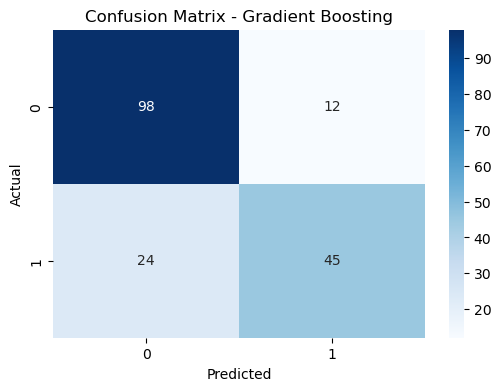

In [48]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Gradient Boosting')

plt.show()